#**Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv('/content/ecommerce_customer_churn_dataset.csv')

#**Data Exporation**

In [ ]:
df.head(5)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  int64  
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [ ]:
df.shape

(50000, 25)

In [ ]:
# Check missing values

df.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
# Check for duplicates

df.duplicated().sum()

np.int64(0)

# **Create missing_summary table**

In [ ]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(by='Missing_Percentage', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Product_Reviews_Written,3500,7.000
Discount_Usage_Rate,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


#### Created a missing data summary table to quantify data quality issues.
####The missing percentage is low, stick to imputing values.

# **Split columns up into 3 categories**

##true_missing
##behavior_missing
##uncertain_missing


In [ ]:
true_missing = [
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Days_Since_Last_Purchase',
    'Email_Open_Rate'
]

behavioral_missing = [
    'Wishlist_Items',
    'Returns_Rate',
    'Product_Reviews_Written',
    'Social_Media_Engagement_Score',
    'Mobile_App_Usage'
]

uncertain_missing = [
    'Discount_Usage_Rate',
    'Payment_Method_Diversity',
    'Credit_Balance'
]

print("True Missing:", true_missing)
print("Behavioral Missing:", behavioral_missing)
print("Uncertain Missing:", uncertain_missing)

True Missing: ['Session_Duration_Avg', 'Pages_Per_Session', 'Days_Since_Last_Purchase', 'Email_Open_Rate']
Behavioral Missing: ['Wishlist_Items', 'Returns_Rate', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage']
Uncertain Missing: ['Discount_Usage_Rate', 'Payment_Method_Diversity', 'Credit_Balance']


####Categorized missing data into true missing, behavioral indicators, and uncertain fields, enabling more accurate and context-aware data preprocessing.

# **Create Missing Flags**

In [ ]:
for col in behavioral_missing:
    df[col + "_Missing_Flag"] = df[col].isnull().astype(int)

####Engineered missing data flags to capture user inactivity signals, enabling analysis of how feature engagement impacts churn and customer value.

#**Missing vs Churn Analysis**

In [ ]:
churn_analysis = {}

for col in behavioral_missing:
    flag_col = col + "_Missing_Flag"

    churn_rate = df.groupby(flag_col)['Churned'].mean()

    churn_analysis[col] = churn_rate

churn_analysis

{'Wishlist_Items': Wishlist_Items_Missing_Flag
 0    0.288957
 1    0.289500
 Name: Churned, dtype: float64,
 'Returns_Rate': Returns_Rate_Missing_Flag
 0    0.288031
 1    0.298820
 Name: Churned, dtype: float64,
 'Product_Reviews_Written': Product_Reviews_Written_Missing_Flag
 0    0.288151
 1    0.300286
 Name: Churned, dtype: float64,
 'Social_Media_Engagement_Score': Social_Media_Engagement_Score_Missing_Flag
 0    0.287932
 1    0.296833
 Name: Churned, dtype: float64,
 'Mobile_App_Usage': Mobile_App_Usage_Missing_Flag
 0    0.289178
 1    0.287400
 Name: Churned, dtype: float64}

####Contrary to expectations, missing engagement features did not significantly impact churn rates, indicating that broader behavioral patterns—rather than isolated feature usage—are more important in predicting customer attrition.

# **Missing vs Lifetime Value (LTV)**

In [ ]:
ltv_analysis = {}

for col in behavioral_missing:
    flag_col = col + "_Missing_Flag"

    ltv_avg = df.groupby(flag_col)['Lifetime_Value'].mean()

    ltv_analysis[col] = ltv_avg

ltv_analysis

{'Wishlist_Items': Wishlist_Items_Missing_Flag
 0    1441.646354
 1    1428.895583
 Name: Lifetime_Value, dtype: float64,
 'Returns_Rate': Returns_Rate_Missing_Flag
 0    1441.157343
 1    1435.244948
 Name: Lifetime_Value, dtype: float64,
 'Product_Reviews_Written': Product_Reviews_Written_Missing_Flag
 0    1439.948018
 1    1449.637646
 Name: Lifetime_Value, dtype: float64,
 'Social_Media_Engagement_Score': Social_Media_Engagement_Score_Missing_Flag
 0    1439.432349
 1    1449.381872
 Name: Lifetime_Value, dtype: float64,
 'Mobile_App_Usage': Mobile_App_Usage_Missing_Flag
 0    1442.488552
 1    1423.865950
 Name: Lifetime_Value, dtype: float64}

####Customer lifetime value appears relatively stable regardless of individual feature engagement, suggesting that value is driven by a combination of behaviors rather than any single interaction metric.

## Missing Features do not relate to churn based on my analysis' above.

## Days Since Last Purchase vs Churn

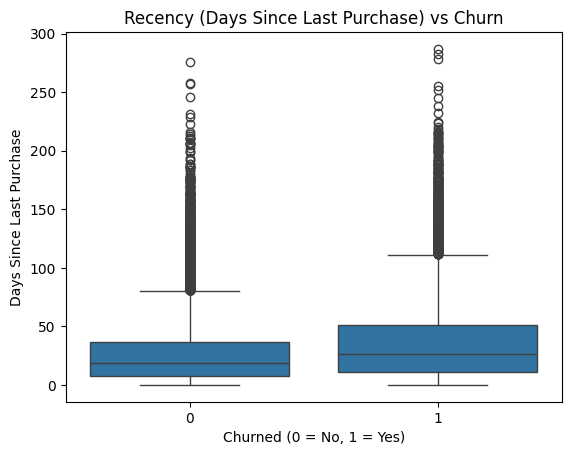

In [ ]:
sns.boxplot(x='Churned', y='Days_Since_Last_Purchase', data=df)

plt.title('Recency (Days Since Last Purchase) vs Churn')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Days Since Last Purchase')

plt.show()

#### Customers who churn tend to have longer inactivate periods, confirming recency as a primary indicator of churn risk.

## Login Frequency vs Churn

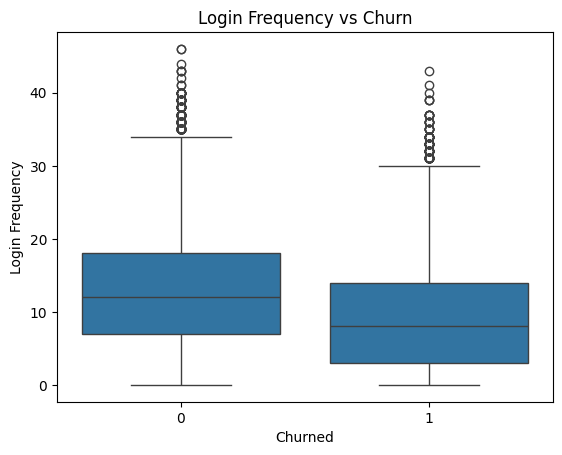

In [ ]:
sns.boxplot(x='Churned', y='Login_Frequency', data=df)

plt.title('Login Frequency vs Churn')
plt.xlabel('Churned')
plt.ylabel('Login Frequency')

plt.show()

#### Customers with lower platform engagement are more likely to churn, confirming engagement as a key retention driver.

## Cart Abandonment Rate vs Churn

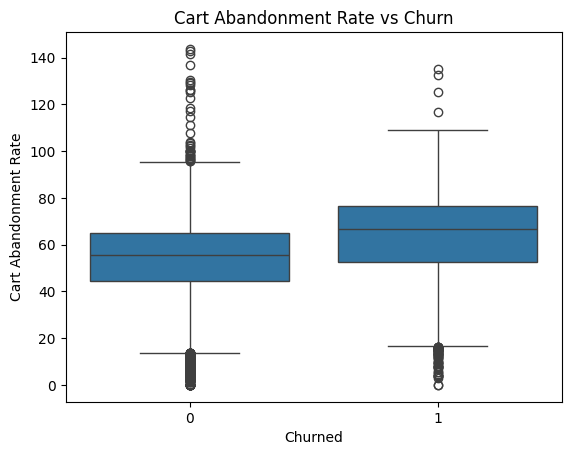

In [ ]:
sns.boxplot(x='Churned', y='Cart_Abandonment_Rate', data=df)

plt.title('Cart Abandonment Rate vs Churn')
plt.xlabel('Churned')
plt.ylabel('Cart Abandonment Rate')

plt.show()

#### Customers with higher rates of abandoning their cart tend to churn, suggesting friction in the purchase process contributes to customer attrition.

# Churn Modeling

In [ ]:
# Select the features
features = [
    'Days_Since_Last_Purchase',
    'Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate'
]

X = df[features]
y = df['Churned']

In [ ]:
# Handle Missing Values
# using the median value

X = X.fillna(X.median())

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Evaluate Model

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.97      0.86      7130
           1       0.78      0.27      0.40      2870

    accuracy                           0.77     10000
   macro avg       0.77      0.62      0.63     10000
weighted avg       0.77      0.77      0.72     10000



#### Model is good at identifying non-churners (77% Accuracy), but bad at catching actual churners (27% Recall). Class imbalance may play a role in the difficulty of discovering at risk users.



In [ ]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

importance

,Feature,Coefficient
4,Cart_Abandonment_Rate,0.033008
0,Days_Since_Last_Purchase,0.011801
1,Login_Frequency,-0.005661
2,Session_Duration_Avg,-0.007249
5,Discount_Usage_Rate,-0.009153
3,Pages_Per_Session,-0.048301


### **Model Insight**
##### Developed a logistic regression model to predict customer churn, achieving 77% accuracy. Identified key behavioral drivers including cart abandonment and purchase recency as primary indicators of churn risk.

### **Behavioral Insight**
##### Customers exhibiting high cart abandonment and longer inactivity periods are significantly more likely to churn, highlighting friction in the purchase process and disengagement as critical risk factors.

### **Engagement Insight**
##### Higher engagement levels (measured by session activity and pages viewed) are associated with reduced churn, emphasizing the importance of sustained platform interaction.

### **Model Limitation**
##### Model performance indicated lower recall for churned customers, suggesting the need for further optimization to better identify at-risk users.




# **Univariate Analysis**

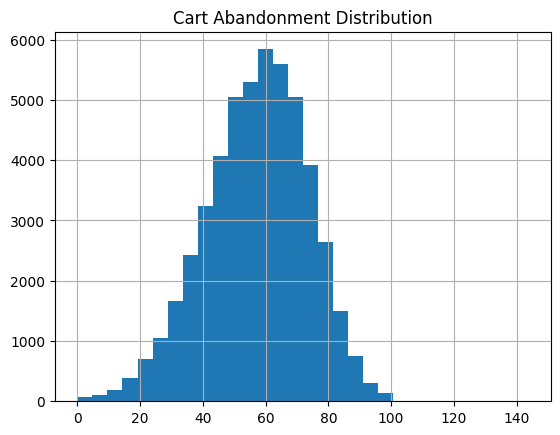

In [ ]:
df['Cart_Abandonment_Rate'].hist(bins=30)
plt.title('Cart Abandonment Distribution')
plt.show()

#### Normal bell curve. Clustered from 40-60

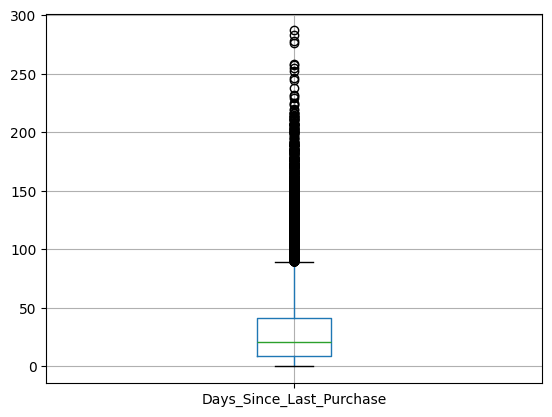

In [ ]:
df.boxplot(column='Days_Since_Last_Purchase')
plt.show()

#### Many outliers

# **Univariate Analysis**

In [ ]:
df[['Cart_Abandonment_Rate',
    'Days_Since_Last_Purchase',
    'Pages_Per_Session',
    'Session_Duration_Avg']].describe()

,Cart_Abandonment_Rate,Days_Since_Last_Purchase,Pages_Per_Session,Session_Duration_Avg
count,50000.000000,47000.000000,47000.000000,46601.000000
mean,57.079973,29.792872,8.737811,27.660754
std,16.282723,29.695062,3.778220,10.871013
min,0.000000,0.000000,1.000000,1.000000
25%,46.400000,9.000000,6.000000,19.700000
50%,58.100000,21.000000,8.400000,26.800000
75%,68.700000,41.000000,11.200000,34.700000
max,143.743350,287.000000,24.100000,75.600000


#### Univariate analysis of key behavioral metrics revealed high cart abandonment rates, a long tail of inactive users, and significant variation in engagement levels. These findings align with the churn model, reinforcing recency and purchase friction as primary drivers of customer attrition, while higher engagement correlates with retention.

## **Data Quality Issue**
#### Identified potential data quality inconsistencies in cart abandonment metrics, with values exceeding logical thresholds, suggesting the need for metric validation.

# **Bivariate Analysis**

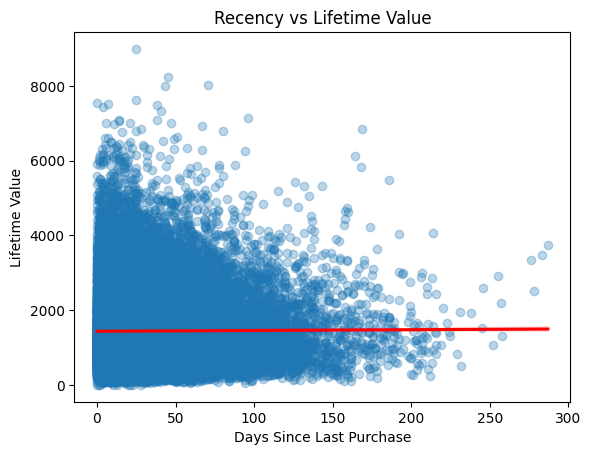

In [ ]:
# Recency vs Lifetime Value

sns.regplot(
    x='Days_Since_Last_Purchase',
    y='Lifetime_Value',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color': 'red'}
)

plt.title('Recency vs Lifetime Value')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Lifetime Value')

plt.show()

#### Recency does not show a strong relationship with lifetime value, suggesting that while inactivity is a key indicator of churn risk, it does not necessarily reflect the total historical value generated by a customer.

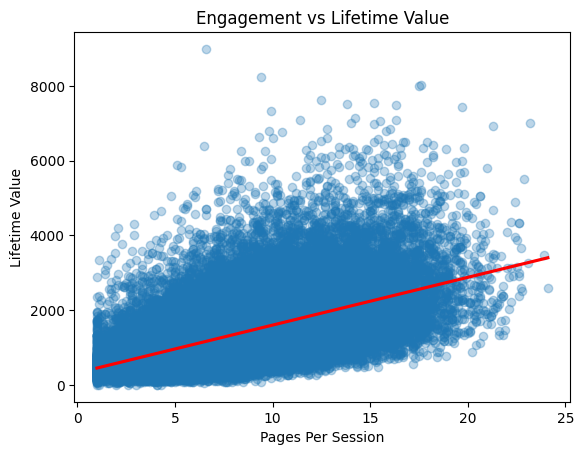

In [ ]:
# Engagement vs Lifetime Value

sns.regplot(
    x='Pages_Per_Session',
    y='Lifetime_Value',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color': 'red'}
)

plt.title('Engagement vs Lifetime Value')
plt.xlabel('Pages Per Session')
plt.ylabel('Lifetime Value')

plt.show()

#### Higher engagement levels are positively associated with increased customer lifetime value, indicating that users who interact more frequently and deeply with the platform contribute significantly more revenue.

#### 💡Invest in:
##### - UX improvements
##### - Personalization
##### - Content discovery

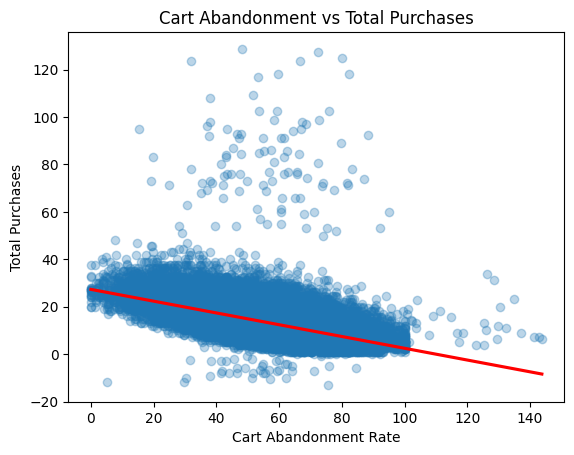

In [ ]:
# Cart Abandonment vs Total Purchases

sns.regplot(
    x='Cart_Abandonment_Rate',
    y='Total_Purchases',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color': 'red'}
)

plt.title('Cart Abandonment vs Total Purchases')
plt.xlabel('Cart Abandonment Rate')
plt.ylabel('Total Purchases')

plt.show()

#### Higher cart abandonment rates are associated with lower purchase frequency, suggesting that friction in the checkout process directly reduces conversion and overall sales.

#### 💡Fix:
##### - Checkout UX
##### - Pricing transparency
##### - Payment options

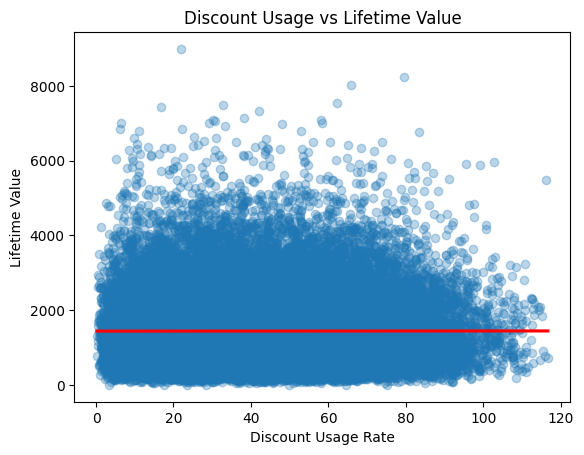

In [ ]:
# Discount Usage vs Lifetime Value

sns.regplot(
    x='Discount_Usage_Rate',
    y='Lifetime_Value',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color': 'red'}
)

plt.title('Discount Usage vs Lifetime Value')
plt.xlabel('Discount Usage Rate')
plt.ylabel('Lifetime Value')

plt.show()

##### Discount usage does not exhibit a strong relationship with customer lifetime value, suggesting that promotional incentives may not significantly influence long-term revenue generation.

#### 💡Fix:
##### - Discounts may drive short-term sales
##### - But not long-term value

#### Bivariate analysis revealed that customer engagement is a primary driver of lifetime value, while cart abandonment significantly reduces purchase frequency. Recency strongly influences churn risk but does not directly impact historical revenue, and discount usage shows limited effect on long-term customer value.

In [ ]:
# Export clean dataset

df.to_csv("ecommerce_customer__churn_clean.csv", index=False)

In [ ]:
# Download clean dataset

from google.colab import files
files.download("ecommerce_customer__churn_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>